## Capital Asset Pricing Model

### E(r$_{a}$) = r$_{f}$ + $\beta_{a}$ ( E[r$_{m}$] - r$_{f}$ ) 

where
### r$_{a}$ = return of a stock/portfolio, r$_{f}$ = risk-free return, E[r_{m}] - r$_{f}$ = market premium ( S&P 500 return - stock/portfolio return) 
### $\beta_{a}$ = Cov (r$_{a}$, r$_{m}$) / Var ( r$_{m}$ )

#### $\beta$ = 1 : stock/portfolio moving exactly with the market
#### $\beta$ > 1 : stock/portfolio is more volatile than the market
#### $\beta$ < 1 : stock/portfolio is less volatile than the market

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
# market interest rate
RISK_FREE_RATE = 4.25
# we will consider monthly returns - and we want to calculate the annual return
MONTHS_IN_YEAR = 12

In [13]:
class CAPM:

    def __init__(self, stocks, start_date, end_date):
        self.data = None
        self.stocks = stocks
        self.start_date = start_date
        self.end_date = end_date

    def download_data(self):
        data = {}

        for stock in self.stocks:
            ticker = yf.download(stock, self.start_date, self.end_date, auto_adjust=False)
        
            # FIX: Access the stock sub-column to get a Series instead of a DataFrame
            data[stock] = ticker['Adj Close'][stock] 

        return pd.DataFrame(data)

    def initialize(self):
        stock_data = self.download_data()
        # we use monthly returns instead of daily returns
        stock_data = stock_data.resample('M').last()

        self.data = pd.DataFrame({'s_adjclose': stock_data[self.stocks[0]],
                                  'm_adjclose': stock_data[self.stocks[1]]})

        # logarithmic monthly returns
        self.data[['s_returns', 'm_returns']] = np.log(self.data[['s_adjclose', 'm_adjclose']] /
                                                       self.data[['s_adjclose', 'm_adjclose']].shift(1))

        # remove the NaN values
        self.data = self.data[1:]

        display(self.data)

    def calculate_beta(self):
        # covariance matrix: the diagonal items are the variances
        # off diagonals are the covariances
        # the matrix is symmetric: cov[0,1] = cov[1,0] !!!
        covariance_matrix = np.cov(self.data["s_returns"], self.data["m_returns"])
        # calculating beta according to the formula
        beta = covariance_matrix[0, 1] / covariance_matrix[1, 1]
        print("Beta from formula: ", beta)

    def regression(self):
        # using linear regression to fit a line to the data
        # [stock_returns, market_returns] - slope is the beta
        beta, alpha = np.polyfit(self.data['m_returns'], self.data['s_returns'], deg=1)
        print("Beta from regression: ", beta)
        # calculate the expected return according to the CAPM formula
        # we are after annual return (this is why multiply by 12)
        expected_return = RISK_FREE_RATE + beta * (self.data['m_returns'].mean()*MONTHS_IN_YEAR
                                                   - RISK_FREE_RATE)
        print("Expected return after a year: ", expected_return)
        self.plot_regression(alpha, beta)

    def plot_regression(self, alpha, beta):
        fig, axis = plt.subplots(1, figsize=(20, 10))
        axis.scatter(self.data["m_returns"], self.data['s_returns'],
                     label="Data Points")
        axis.plot(self.data["m_returns"], beta * self.data["m_returns"] + alpha,
                  color='red', label="CAPM Line")
        plt.title('Capital Asset Pricing Model, finding alpha and beta')
        plt.xlabel('Market return $R_m$', fontsize=18)
        plt.ylabel('Stock return $R_a$', fontsize=18)
        plt.text(0.08, 0.05, r'$R_a = \beta * R_m + \alpha$', fontsize=18)
        plt.legend()
        plt.grid(True)
        plt.show()

### Calculate $\beta$ for NVDA and use S&P 500 as market

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
C:\Users\arabi\AppData\Local\Temp\ipykernel_36844\4275667766.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  stock_data = stock_data.resample('M').last()


,s_adjclose,m_adjclose,s_returns,m_returns
Date,,,,
2023-02-28,23.191525,3970.149902,0.172531,-0.026459
2023-03-31,27.752432,4109.310059,0.179537,0.034451
2023-04-30,27.724457,4169.479980,-0.001009,0.014536
2023-05-31,37.800529,4179.830078,0.310008,0.002479
2023-06-30,42.268955,4450.379883,0.111730,0.062719
2023-07-31,46.692501,4588.959961,0.099531,0.030664
2023-08-31,49.316456,4507.660156,0.054674,-0.017875
2023-09-30,43.468605,4288.049805,-0.126219,-0.049946
2023-10-31,40.751507,4193.799805,-0.064546,-0.022225


Beta from formula:  1.9020633998494716
Beta from regression:  1.90206339984947
Expected return after a year:  -3.5110196210148956


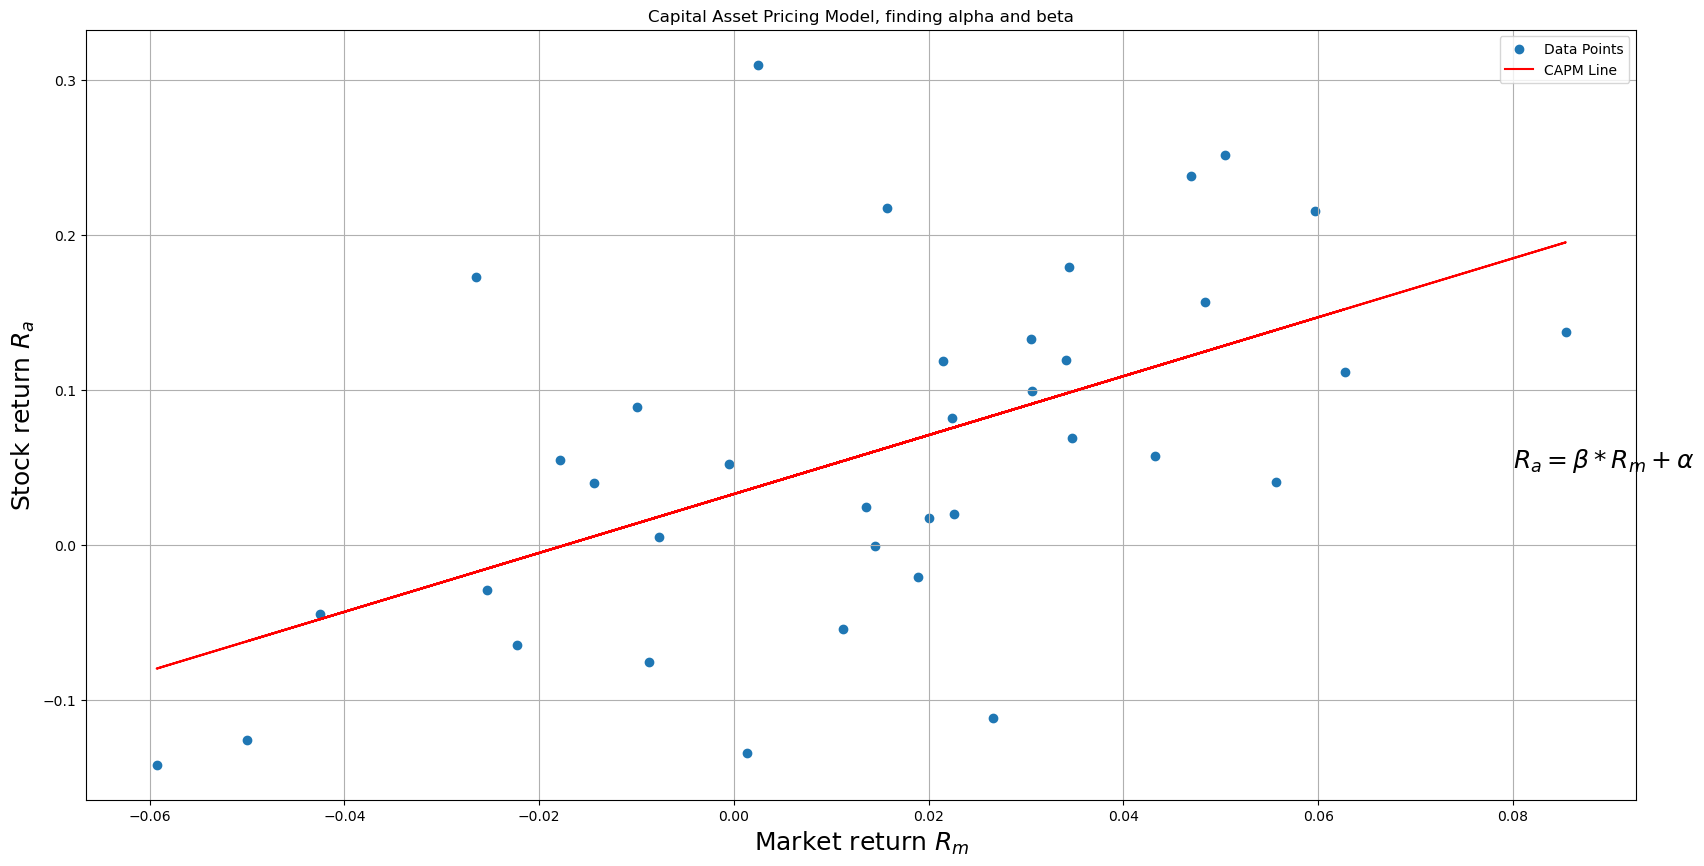

In [14]:
capm = CAPM(['NVDA', '^GSPC'], '2023-01-01', '2026-03-01')
capm.initialize()
capm.calculate_beta()
capm.regression()